## 1.2 应用

一旦建立输入输出关系，便可应用于多种场景，例如系统优化或系统控制。下文列举若干实际案例。

克里希纳等人（2024）致力于寻找稳定的晶体结构。然而，在实验室中制备具有不同晶体结构的材料并研究其稳定性，过程繁琐、成本高昂且十分耗时。自然界中存在的晶体结构通常具备较低的势能。因此，一种更为可行的方法是借助密度泛函理论（DFT）计算晶体结构的势能，进而找到使势能最小的最优原子构型。尽管该计算方法成本更低，但相关研究依旧存在不小难度：密度泛函理论计算开销大，且可供探索的原子构型空间十分庞大。除此之外，势能面存在大量局部极小值（例如石墨与金刚石就是碳原子的两种不同构型），进一步增加了问题的复杂程度。试验设计方法能够高效搜寻庞大的原子构型空间，以最少的密度泛函理论计算寻找到全局最优解。

黄等人（2021）阐述了制备用于化学分离的杂化膜所面临的问题。将金属颗粒注入聚合物膜内制备杂化膜，使其在化学分离过程中不易溶解，该制备过程采用气相渗透工艺。任等人（2021）建立了反应-扩散模型，用以预测聚合物膜中截留的金属颗粒含量。但该模型包含五个未知参数（如扩散常数），需要确定参数数值后模型才可用于预测。这属于模型校准问题，然而常规非线性回归方法难以求解，原因在于该计算机模型的运算成本较高。因此，需要借助试验设计方法高效解决该问题。

古尔等人（2018）报道了一家机械加工软件公司遇到的问题。实体立铣仿真过程中的仿真器具有确定性，即在相同输入参数设置下，输出的切向力结果保持一致。但在实际工况中，刀具会发生磨损，工件材料特性也存在件间差异。因此，实际输出的作用力不会与仿真预测值完全吻合，作用力大小会随刀具状态与材料状态产生一定波动。这家软件公司希望为预测结果增设置信区间，量化输入参数带来的不确定性。构建该置信区间的一种简易方法是采用蒙特卡洛（MC）方法：从输入参数的分布中抽取随机样本，运行仿真器得到一组输出曲线，基于这些曲线即可求解例如 95% 置信区间。若选取大量蒙特卡洛样本，得到的置信区间将具备较高精度。然而该方案效率偏低，原因在于仿真运算成本较高。对此，可借助试验设计方法，从输入分布中进行最优采样并实现不确定性传递，从而节约仿真耗时。

上述实例的研究目标各不相同：第一个晶体结构相关问题属于优化问题，第二个膜相关问题为标定问题，第三个机械加工相关问题则涉及不确定性传递。不存在一套适用于所有这类问题的最优试验设计方案。实际上，最优试验设计会随研究目标与响应曲面类型的变化而改变。图 1.4 展示了若干基于一维函数的示例。举例而言，若目标是近似拟合响应曲面：当响应曲面起伏较大时，采用均匀填充样本空间的设计方案效果较好（图 1.4 左上子图）；而当函数曲线平滑时，在边界附近布置更多样本点的设计方案更为合适（右上子图）。倘若目标是求取函数最大值，则应在全局最大值附近布置更多设计点（左下子图）。与之相对，若研究目标为不确定性传递，设计点的布置方式需要贴合输入量的分布特征（右下子图，图中曲线代表输入量的概率密度）。

> **图 1.4** 针对不同目标的最优实验设计（实心圆点）。

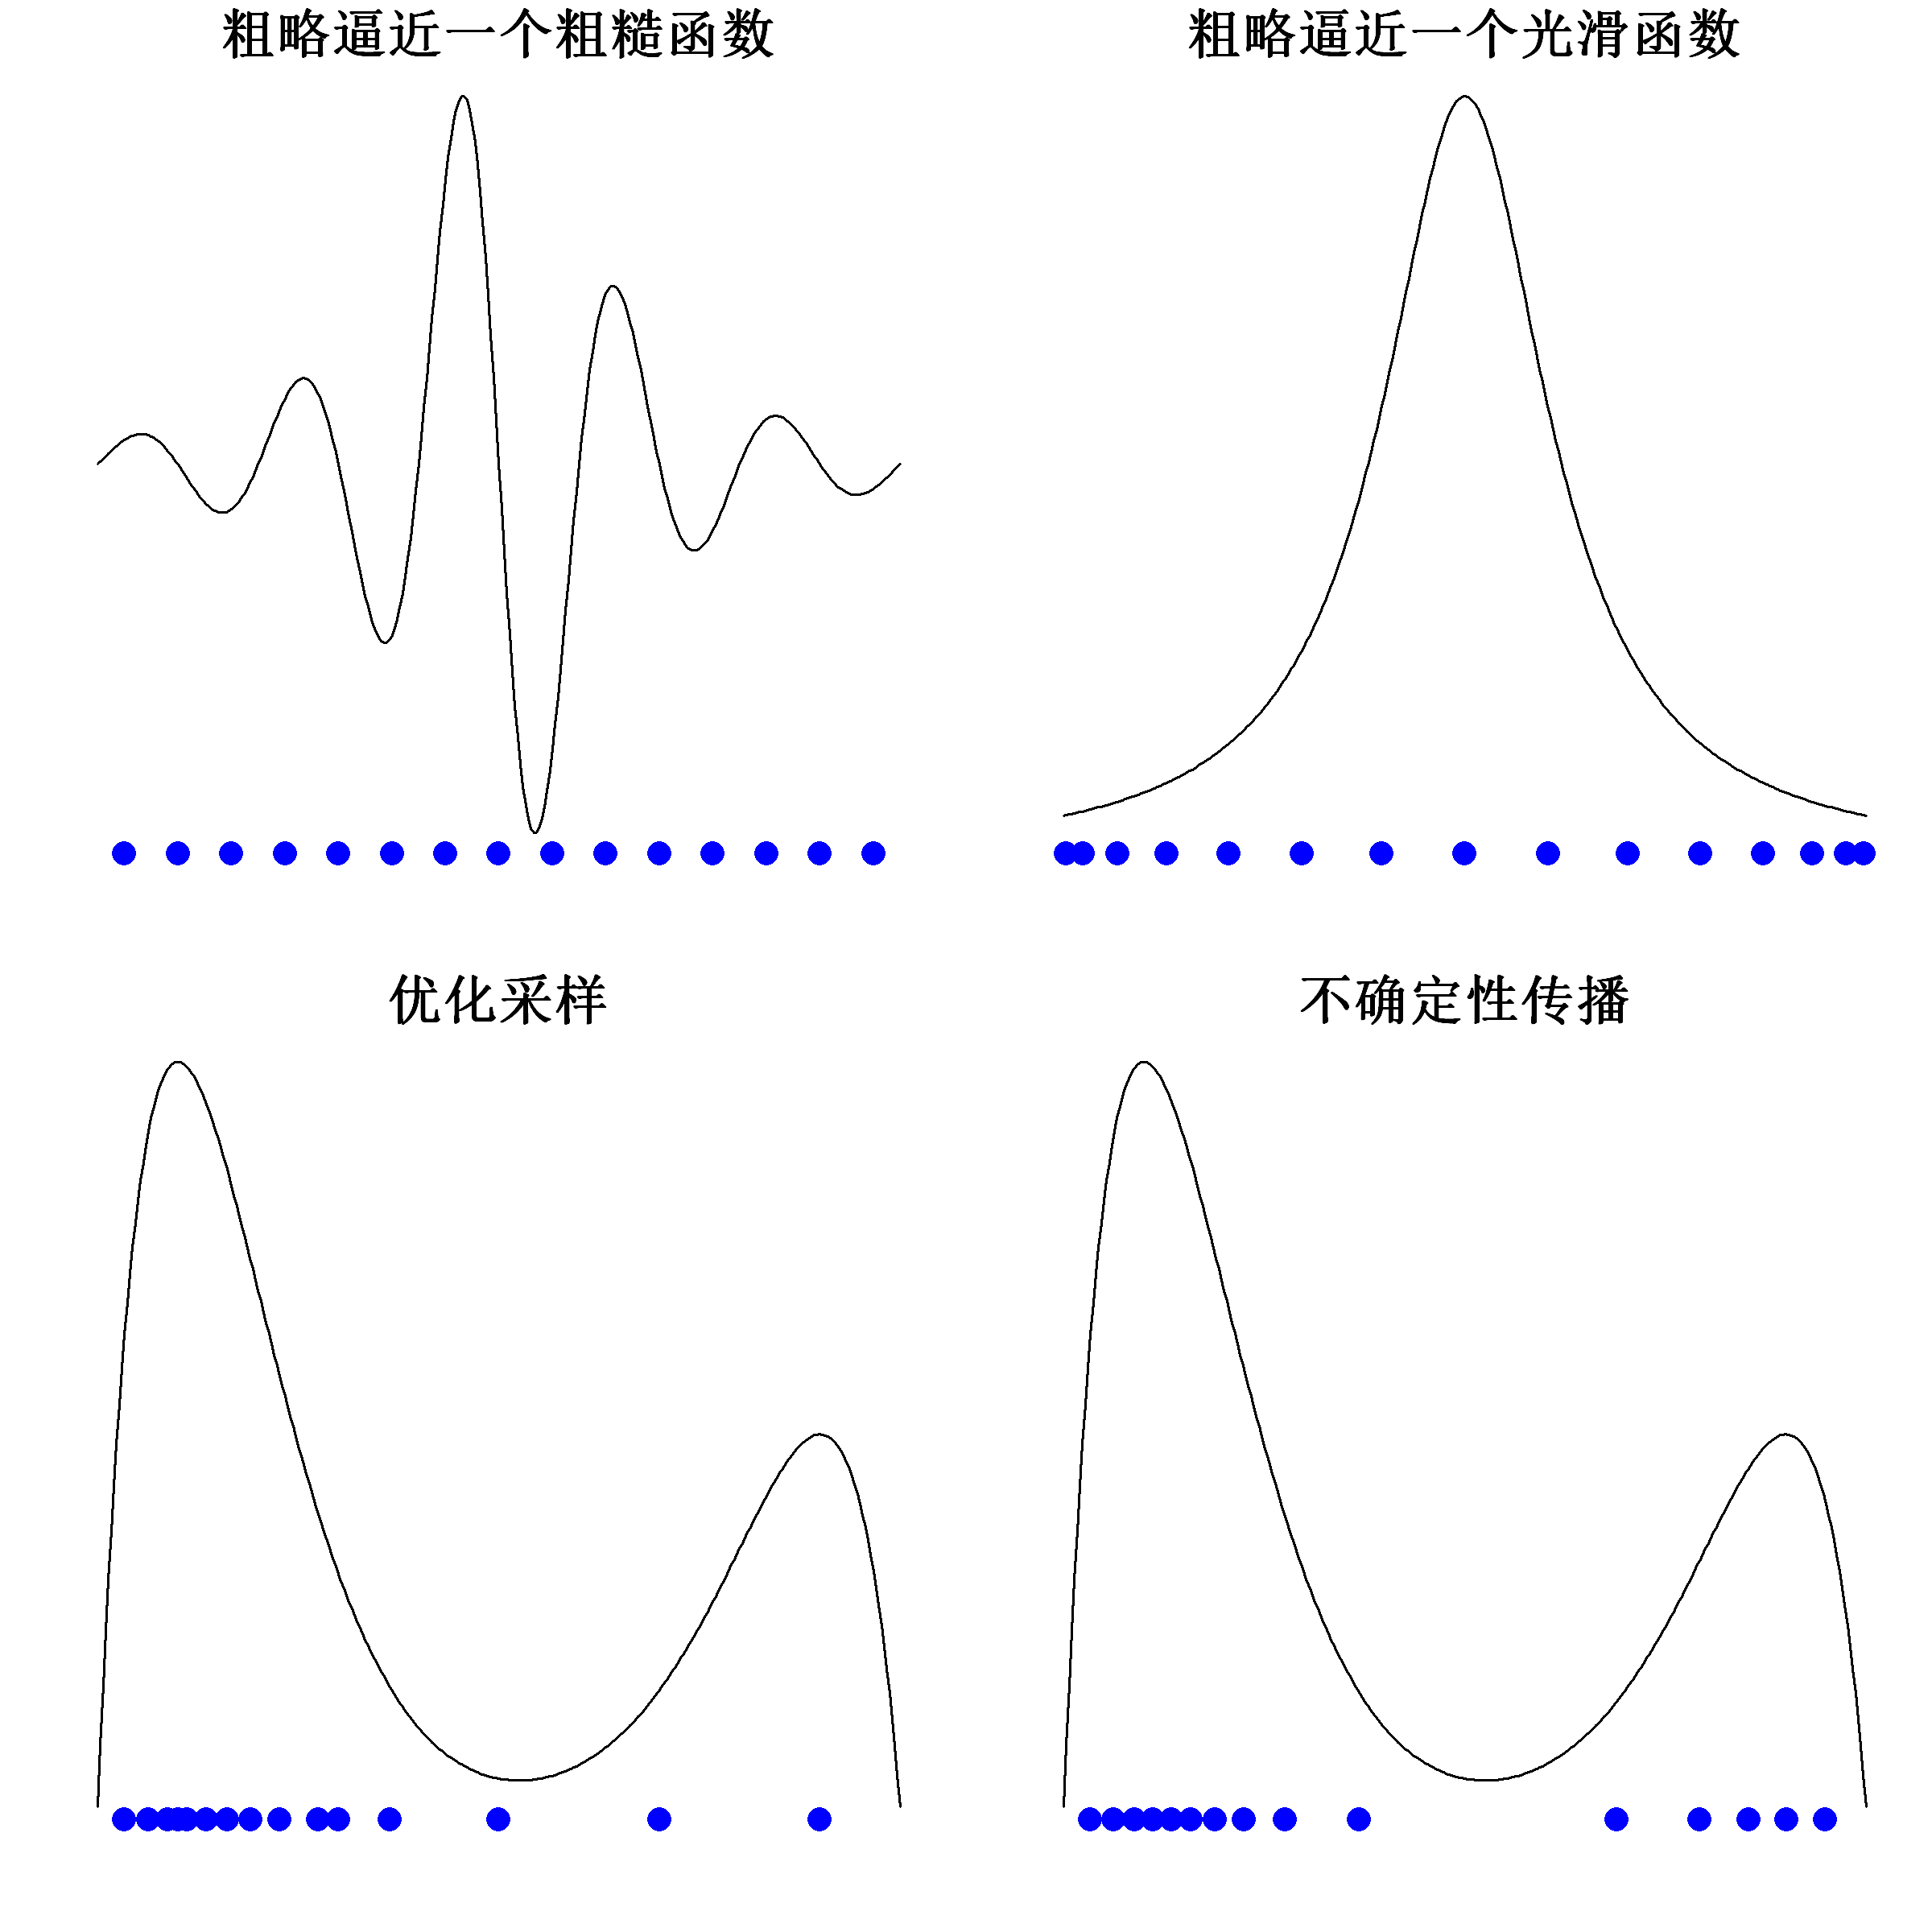

In [1]:
# 图 1.4

options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
x=seq(0,1,length=301)
y=sin(10*pi*x)/(1+64*(x-.5)^2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="粗略逼近一个粗糙函数",cex.main=4)
n=15
D=((1:n)-.5)/n
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")

y=1/(1+64*(x-.5)^2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="粗略逼近一个光滑函数",cex.main=4)
D=qbeta(((1:n)-.5)/n,.5,.5)
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")

y=2/3*dbeta(x,2,10)+1/3*dbeta(x,10,2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="优化采样",cex.main=4)
n1=n*2/3;n2=n/3
D0=((1:n2)-.5)/n2
D=c(D0,qbeta(((1:n1)-.5)/n1,2,10))
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")

y=2/3*dbeta(x,2,10)+1/3*dbeta(x,10,2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="不确定性传播",cex.main=4)
set.seed(1)
x=c(rbeta(1000*n1,2,10),rbeta(1000*n2,10,2))
library(support)
D=sp(n,1,dist.samp=cbind(x))$sp
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")
par(mfrow=c(1,1))

试验设计规定了数据的采集位置。因此，在寻找最优试验设计时，我们手中暂无任何数据。换言之，开展试验设计阶段，我们对响应曲面一无所知。然而图 1.4 表明，最优试验设计依赖于底层响应曲面（最后一种情况除外）。由此可见，求解最优试验设计看似是一个定义不明确的问题。所幸存在一种解决思路：我们无需预先确定全部试验点。可以先构建初始设计、采集数据，再确定下一组试验的开展位置。该方法被称为序贯设计方法（在机器学习相关文献中也称作主动学习）。对于初始设计而言，图 1.4 左上角子图中均匀分布的试验点是一种较为理想的方案，这类设计称为空间填充设计，后续章节将对其展开详细讨论。

## 1.3 不确定性的作用

如果我们能够充分掌握底层响应曲面的全部信息，就无需采集数据或是开展任何实验。正是由于对响应曲面存在认知不确定性，我们才需要开展实验、收集数据。数据能够带来新信息，降低我们对响应曲面的认知不确定性。因此，开展能够最大化信息获取量或最小化不确定性的实验具备现实意义。正如林德利（1956）所述，最优实验设计理论可以借助信息论（香农，1948）中的相关概念构建。不过，只要具备量化不确定性的方法，本书探讨的绝大多数实验设计方法，无需深入研究信息论也能够推导得出。我们将采用若干统计建模方法对不确定性进行量化。

为探讨建模方法，我们首先引入一些符号。设 $\boldsymbol{x} = (x_1, \dots, x_p)'$ 为 $p$ 个输入变量（也称为影响因子），$y$ 为输出变量（或称响应值）。系统可能存在多个输出变量，但多数情况下，只需针对多输入单输出系统构建建模方法，之后可将该方法分别应用于各个输出变量。假设统计模型：$$y = h(\boldsymbol{x}) + \epsilon\tag{1.1}$$ 式中 $h(\boldsymbol{x})$ 代表输入输出关系（响应曲面），$\epsilon$ 为随机误差；该误差由大量其他潜在影响输出、但未纳入实验的因素波动产生。在物理实验中，$\epsilon$ 同时包含仪器带来的测量误差。若实验依托确定性计算机模型开展，则可忽略误差项 $\epsilon$。通常假定 $\epsilon \sim \mathcal{N}(0, \sigma^2)$，其中 $\sigma^2$ 为随机误差的方差。式(1.1)中的正态性假设与加性误差假设未必成立，实际应用中可能需要采用变量变换进行处理（博克斯和考克斯，1964）。

假设我们开展一项单因素试验，该因素设置两个取值（也称为水平）：$x=0$ 和 $x=1$，每种水平设置 3 次重复试验。试验数据如图 1.5 中蓝色实心圆点所示。设 $h(\cdot)$ 为图中黑色实线代表的函数，试验人员并不知晓该函数形式。线性回归模型在物理试验中应用广泛（吴与滨田，2021）。假设我们采用模型 $y_i = \beta_0 + \beta_1x_i + \epsilon_i$ 拟合数据，其中对 $i=1,\dots,n$（本例中$n=6$），$\epsilon_i$ 独立同分布，服从正态分布 $\mathcal{N}(0, \sigma^2)$。拟合得到的直线以及 95% 置信区间展示在图的左侧子图。高斯过程（GP）回归（拉斯穆森、威廉姆斯，2006）在此类场景中较少使用，相关拟合结果同样展示在该图的右侧子图。

> **图 1.5** 线性回归与高斯过程回归的对比。

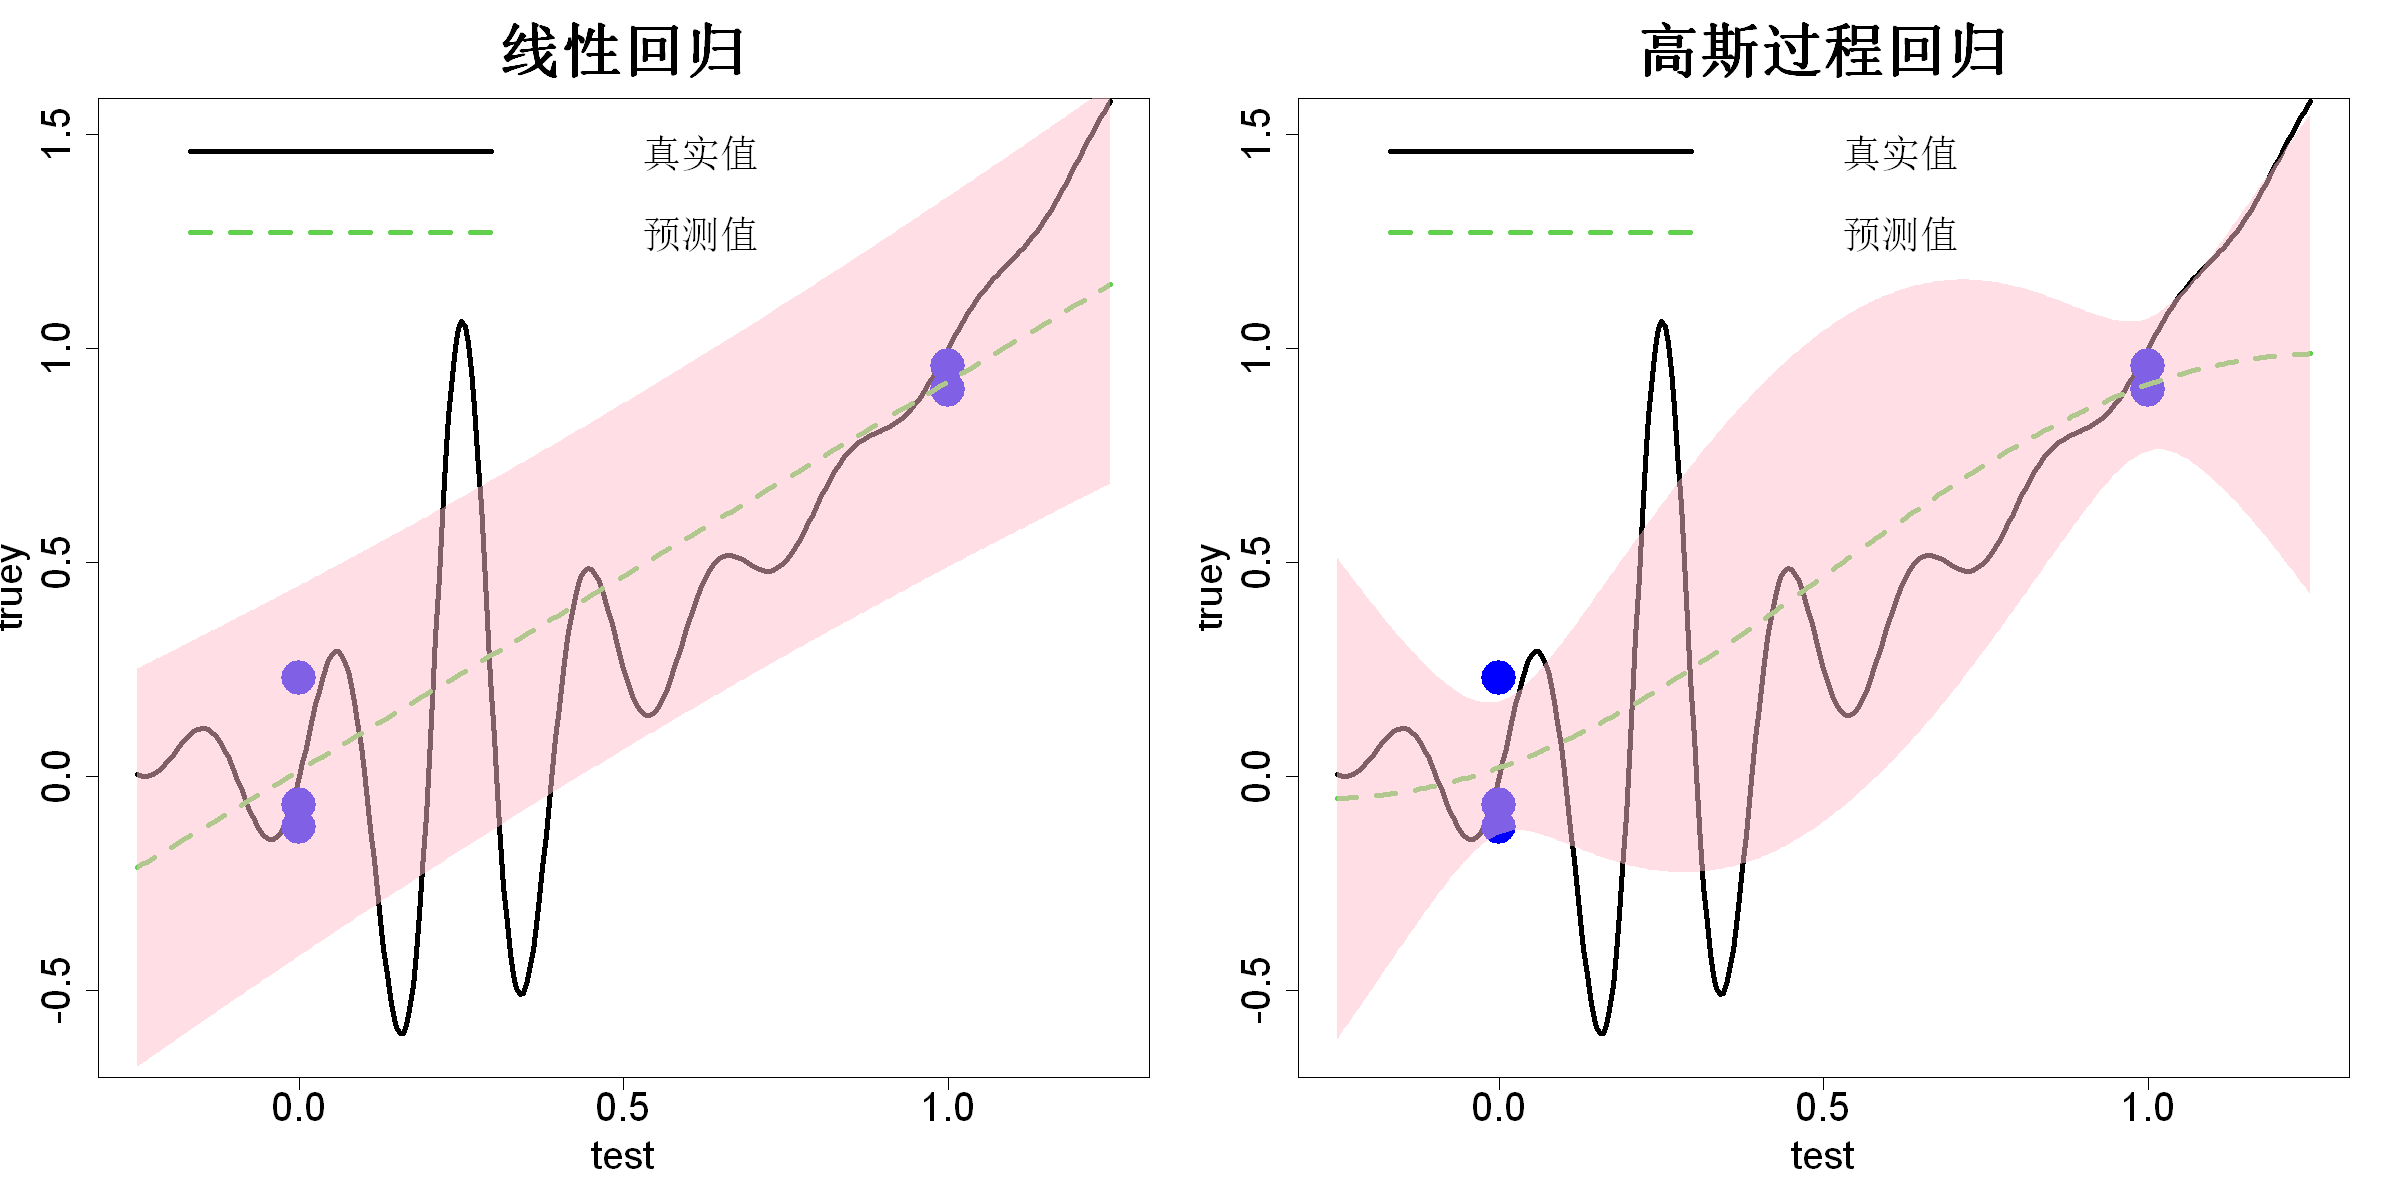

In [2]:
# 图 1.5

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
n=6
x=rep(c(0,1),c(n/2,n/2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
set.seed(7)
y=f(x)+.1*rnorm(n)
l=-.25;u=1.25
test=seq(l,u,length=301)
truey=f(test)
plot(test,truey,type="l",lwd=4,xlim=c(l,u),ylim=c(min(y)-.5,1.5),cex.axis=2,cex.lab=2,main="线性回归",cex.main=3)
points(x,y,pch=16,cex=4,col="blue")

pred=predict.lm(lm(y~x),newdata=data.frame(x=test),interval="prediction")
lines(test,pred[,1],col=3,lwd=4,lty=2)
low=pred[,2]
up=pred[,3]
polygon(c(test,rev(test)),c(low,rev(up)),col=adjustcolor("pink",alpha.f=0.5),border=NA)
legend(-.4,1.65,legend=c("真实值","预测值"),lty=c(1,2),col=c(1,3),lwd=c(4,4),bty="n",cex=2)

plot(test,truey,type="l",lwd=4,xlim=c(l,u),ylim=c(min(y)-.5,1.5),main="高斯过程回归",cex.main=3,cex.axis=2,cex.lab=2)
points(x,y,pch=16,col="blue",cex=4)
library(rkriging)
pred=Fit.Kriging(x,y,interpolation=FALSE,fit=TRUE,model="OK",kernel.parameters=list(type="Gaussian"))|>
Predict.Kriging(data.frame(x=test))
lines(test,pred$mean,col=3,lwd=4,lty=2)
low=pred$mean-2*pred$sd
up=pred$mean+2*pred$sd
polygon(c(test,rev(test)),c(low,rev(up)),col=adjustcolor("pink",alpha.f=0.5),border=NA)
legend(-.4,1.65,legend=c("真实值","预测值"),lty=c(1,2),col=c(1,3),lwd=c(4,4),bty="n",cex=2)
par(mfrow=c(1,1))

尽管线性回归与高斯过程回归（GP回归）得到的预测值大致相同，但二者的预测区间却截然不同。这是由两类模型量化预测不确定性的方式决定的，理解二者之间的差异十分重要。线性回归的预测不确定性包含参数估计（$\hat{\beta}_0$ 和 $\hat{\beta}_1$）带来的不确定性以及随机误差（$\epsilon$）。该模型在取值端点处（$x=0$ 和 $x=1$）不确定性最大，在中点位置（$x=0.5$）不确定性最小。与之不同，高斯过程回归属于非参数回归方法，因此其预测不确定性包含关于函数 $h(\cdot)$ 的不确定性与随机误差。在已有观测数据的位置，它的不确定性最低，而在区间中点处不确定性达到峰值，这与线性回归的特征恰好相反！

绝大多数物理实验的实验设计都是基于线性回归模型构建而成（博克斯等人，1978；蒙哥马利，2017；吴与滨田，2021）。这是否意味着这类实验设计没有实用价值？其实并非如此！当因子数量（$p$）较多，而实验次数（$n$）较少时，高斯过程回归在边界处同样会产生较大不确定性，该现象与线性回归所得结论一致。大多数物理实验都具备该特征（多因子、少实验次数）；因此，采用线性回归框架或高斯过程回归框架大概率会得到相同结果。不过，若依托线性回归框架开展研究，会对最优设计的探索带来一定局限。

假设我们需要针对 6 个连续因子开展试验，试验预算约为 30 次试验（也称为试验运行次数）。研究者可以考虑采用二水平部分因子设计 $2^{6-1}$，该设计需要 32 次试验。除此之外，也可以选用三水平部分因子设计 $3^{6-3}$，该设计仅需 27 次试验；或是采用包含 29 次试验的中心复合设计（12 个轴向点、16 个立方点以及 1 个中心点）。现有试验设计相关文献并未明确说明应当选择上述哪种设计。究其原因，每种设计均预先假定了特定的线性回归模型，并未考虑模型设定错误的可能性。学术界很早就意识到，我们需要构建对模型设定错误具备稳健性的试验设计。但线性回归模型无法完整刻画模型存在的不确定性，这限制了这类设计的实用价值。举例来说，我们可以构造 $2^{6-1}$ 最小低阶混杂设计（弗里斯、亨特，1980），该设计被视作具备模型稳健性的设计（郑等人，1999）。然而，该设计仅对包含主效应、二因子交互效应以及更高阶交互效应的线性回归模型具备稳健性，并未考虑存在非线性效应的情况。

上述讨论表明，相较于线性回归，采用高斯过程回归构建最优设计框架会是更优选择，原因在于高斯过程能够更有效地量化模型不确定性。本书即采用该研究思路。

## 1.4 全书概述

本书探讨的诸多试验设计方法均依赖高斯过程模型，因此我们将在第 2 章对高斯过程建模进行初步介绍。不过，在讲解高斯过程之前，我们先从更为读者熟知的多项式插值入手，在简要介绍径向基函数与克里金法之后，再逐步过渡到高斯过程。文中还探讨了如何将上述方法拓展应用于含噪声数据，这类拓展对第二部分与第四部分的相关方法至关重要。相关论述过程中，也会引入试验设计领域的若干重要概念。

本书第二部分从基于高斯过程（GP）的试验设计方法展开。第 3 章篇幅较短，原因在于这类方法依赖高斯过程模型中未知的超参数，实际应用价值有限。但第 3 章为第 4 至 7 章中更实用、有效的试验设计方法的推导奠定了基础。第 4 章阐述本书关于空间填充设计的若干核心概念。空间填充设计既可看作基于高斯过程模型设计的极限情形，同时具备几何层面的解释。这类设计属于模型稳健设计，适用于各类实际场景。第 5 章将上述思路拓展至非均匀分布场景，为第四部分介绍的数据科学方法搭建理论基础。第 6 章探讨空间填充设计一类极具实用价值的特例，主要用于快速筛选影响因子。本章同时引入全局灵敏度分析中的重要概念，这些概念是第 11 章后续变量筛选方法的理论根基。第7章构建面向特定目标（例如优化问题）的序贯设计方法，第 4 至 6 章提出的各类设计均可作为该方法的初始设计方案。

第三部分中关于部分因子试验设计的第 8 章内容有意精简撰写，原因是已有大量优秀教材专门阐述该主题。但本章依旧值得读者研读，因为它尝试将内容与第一、二部分介绍的多种试验设计及建模方法建立关联。第 9 章则探讨同时拥有计算机仿真实验与实物实验数据的情形。

第四部分介绍了试验设计方法在二次抽样（第 10 章）与数据分析（第 11 章）中的应用。在统计学领域，试验设计传统上被视作一种数据收集与方案规划手段。本书纳入该部分内容，旨在让读者认识试验设计广泛的适用场景，并夯实其作为统计学基础课题的地位。